# M5 · Best Ensemble Run
Runs the best per-segment ensemble found by HPO.
Each segment gets its own Chronos-2 model with its own context length;
forecasts are filtered to that segment's IDs, then concatenated before evaluation.

Tag format matches `hpo_zs_withcov_ensembles.ipynb` (ZS) and `hpo_ft_ensembles.ipynb` (FT)
so any forecast already cached by the HPO study is **reused automatically**.

# 1 · Imports

In [1]:
import os
import sys
sys.path.append("/home/nmwamsojo/tsfm-explo/src/jobs/")

import gc
import torch
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from IPython.display import display

from m5_dataprep import M5DataPipeline
from m5_exploration import (
    M5ExplorationSuite,
    DEFAULT_CHRONOS_CONFIG,
)
from m5_evaluator import M5Evaluator

print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")

/home/nmwamsojo/tsfm-explo/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


CUDA available: True
  GPU 0: Quadro RTX 5000
  GPU 1: Quadro RTX 5000


In [2]:
os.environ["OMP_NUM_THREADS"]        = "1"
os.environ["MKL_NUM_THREADS"]        = "1"
os.environ["OPENBLAS_NUM_THREADS"]   = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"]    = "1"
os.environ["CUDA_VISIBLE_DEVICES"]   = "0,1"

INFERENCE_DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"

# 2 · Config
**Edit this cell only.** Paste the best-trial values from HPO results.

In [3]:
# ── Data ──────────────────────────────────────────────────────────────────────
DATA_PATH     = "/mnt/lab/datasets/M5/jointed_M5.parquet"
CALENDAR_PATH = "/mnt/lab/nmwamsojo/m5_data/calendar.csv"
ACTUALS_PATH  = "/mnt/lab/nmwamsojo/m5_data/sales_test_evaluation.csv"
DATA_TAG      = "sales_only"   # must match the HPO study that produced BEST_CL

CUTOFF_DAY = (
    pd.to_datetime("2016-05-22") - pd.Timedelta(days=0)
).strftime("%Y-%m-%d")
print(f"Cutoff day : {CUTOFF_DAY}")
print(f"Data tag   : {DATA_TAG}")

# ── Segmentation ──────────────────────────────────────────────────────────────
seg_columns = "smoothness_segs"   # "weight_segs"  or  "smoothness_segs"

# ── Best ensemble config — paste from HPO best trial ─────────────────────────
# Keys must match the segment names for the chosen seg_columns:
#   weight_segs     → "Low", "Medium-Low", "Medium-High", "High"
#   smoothness_segs → "Smooth", "Erratic", "Intermittent", "Lumpy"
BEST_CL = {
    "Low":         1,    # ← fill from HPO results
    "Medium-Low":  1,
    "Medium-High": 1,
    "High":        256,
}

if "smoothness" in seg_columns:
    BEST_CL = {
        "Smooth":       256,    # ← fill from HPO results
        "Erratic":      1,
        "Intermittent": 1,
        "Lumpy":        1,
    }


COV_TYPE   = "only"  # covariate bundle — must be a key in COVARIATE_OPTIONS
FT_STEPS   = 0             # 0 = zero-shot; >0 = fine-tuned
FT_MODE    = "lora"        # "lora" or "full"  — ignored when FT_STEPS == 0
FT_LR      = 1e-4          # learning rate     — ignored when FT_STEPS == 0
FT_BS      = 64            # fine-tune batch   — ignored when FT_STEPS == 0

BATCH_SIZE = 64    # inference batch size (fixed)
FORCE_RUN  = False  # True → re-infer even if a cached forecast exists on disk

# ── Covariate options (keep in sync with HPO notebooks) ───────────────────────
COVARIATE_OPTIONS = {
    "only":             [],
    "is_weekend":       ["is_friday", "is_saturday", "is_sunday"],
    "event":            ["event_name_1", "event_type_1"],
    "price":            ["sell_price"],
    "snap_CA":          ["snap_CA"],
    "snap_TX":          ["snap_TX"],
    "snap_WI":          ["snap_WI"],
    "is_weekend_event": ["is_friday", "is_saturday", "is_sunday",
                         "event_name_1", "event_type_1"],
    "is_weekend_price": ["is_friday", "is_saturday", "is_sunday", "sell_price"],
    "event_price":      ["event_name_1", "event_type_1", "sell_price"],
    "all":              ["is_friday", "is_saturday", "is_sunday",
                         "event_name_1", "event_type_1", "sell_price"],
}

# ── AutoGluon wrapper ─────────────────────────────────────────────────────────
WRAPPER = {
    "eval_metric":          "RMSSE",
    "enable_ensemble":      False,
    "skip_model_selection": True,
    "verbosity":            1,
}

# ── Base Chronos config — per-segment fields overridden at run time ───────────
CFG_BASE = {
    **DEFAULT_CHRONOS_CONFIG,
    "use_static": False,
    "device":     INFERENCE_DEVICE,
}

# ── Auto-derived ensemble tag (used when saving ensemble metrics) ─────────────
_ft_str = "" if FT_STEPS == 0 else f"_ft{FT_STEPS}_{FT_MODE}"
EXP_ENSEMBLE_TAG = (
    f"ens_best_{seg_columns.replace('_segs', '')}_{COV_TYPE}{_ft_str}"
)
print(f"Ensemble tag : {EXP_ENSEMBLE_TAG}")

Cutoff day : 2016-05-22
Data tag   : sales_only
Ensemble tag : ens_best_smoothness_only


# 3 · Data

In [ ]:
pipeline = M5DataPipeline(config={"tag": DATA_TAG})
hist_df, hist_df_trimmed, future_df, static_df, weights_scales = (
    pipeline.get_prepared_data(DATA_PATH, CUTOFF_DAY, level=12, force_reprepare=False)
)

print(f"\nhist_df         : {hist_df.shape}  cols: {list(hist_df.columns)}")
print(f"hist_df_trimmed : {hist_df_trimmed.shape}")
print(f"future_df       : {future_df.shape}")
print(f"static_df       : {static_df.shape}")
print(f"weights_scales  : {weights_scales.shape}")

del pipeline
gc.collect()

--- Cache Miss: Preparing Level 12 for 2016-05-22 ---
--- Loading: /mnt/lab/datasets/M5/jointed_M5.parquet ---
--- Aggregating to Level 12 ---


In [ ]:
def _wide_to_long(gt_wide: pd.DataFrame, calendar_path: str) -> pd.DataFrame:
    if "id" not in gt_wide.columns:
        gt_wide["id"] = gt_wide["item_id"] + "_" + gt_wide["store_id"] + "_evaluation"
    day_cols = [c for c in gt_wide.columns if c.startswith("d_")]
    long = gt_wide.melt(id_vars=["id"], value_vars=day_cols,
                        var_name="d", value_name="sales_quantity")
    cal = pd.read_csv(calendar_path, usecols=["d", "date"])
    cal["date"] = pd.to_datetime(cal["date"])
    long = long.merge(cal, on="d", how="left").drop(columns=["d"])
    long["id"] = long["id"].str.replace("_evaluation", "", regex=False)
    return long[["id", "date", "sales_quantity"]]


if CUTOFF_DAY == "2016-05-22":
    _eval_raw = pd.read_csv(ACTUALS_PATH)
    df_actual = _wide_to_long(_eval_raw, CALENDAR_PATH)
    del _eval_raw
else:
    df_actual = (
        pd.read_parquet(DATA_PATH, columns=["id", "date", "sold"])
        .rename(columns={"sold": "sales_quantity"})
    )
    df_actual["id"] = (
        df_actual["id"].astype(str)
        .str.replace("_evaluation", "", regex=False)
        .str.replace("_validation",  "", regex=False)
    )

print(f"Actuals : {df_actual.shape}  |  "
      f"{df_actual['date'].min().date()} \u2192 {df_actual['date'].max().date()}")

Actuals : (59181090, 3)  |  2011-01-29 → 2016-05-22


# 4 · Evaluator & Suite
Initialised once — reused across all segment runs.

In [ ]:
evaluator = M5Evaluator(
    raw_train_df     = hist_df,
    trimmed_train_df = hist_df_trimmed,
    static_df        = static_df,
    weights_df       = weights_scales,
    target_col       = "sales_quantity",
    price_col        = "sell_price",
)
suite = M5ExplorationSuite(
    horizon  = 28,
    ag_path  = "/mnt/lab/nmwamsojo/autogluon_models/explorations",
    base_dir = "/mnt/lab/nmwamsojo/prepared_data",
)

  [CPU] CuPy not available — scale computation on 18 CPU cores.
  Building hierarchy scales and weights …


# 5 · Segment ID Map

In [ ]:
quantile_labels = ["Low", "Medium-Low", "Medium-High", "High"]
weights_scales["weight_segs"] = pd.qcut(
    weights_scales["weight"],
    q=4,
    labels=quantile_labels,
)

In [ ]:
# Resolve segment names and validate BEST_CL keys
if "weight" in seg_columns:
    seg_names    = quantile_labels
    undefined_in = "Low"
else:
    seg_names    = ["Smooth", "Erratic", "Intermittent", "Lumpy"]
    undefined_in = "Lumpy"

# Scheme identifier used in cache tags — matches both HPO notebooks
seg_scheme = seg_columns.replace("_segs", "")   # "weight" or "smoothness"

missing_keys = [s for s in seg_names if s not in BEST_CL]
if missing_keys:
    raise ValueError(f"BEST_CL is missing segment keys: {missing_keys}")

# Build {segment → [id, ...]} map
if seg_columns in hist_df_trimmed.columns:
    _seg_src = hist_df_trimmed[["id", seg_columns]].drop_duplicates()
else:
    _seg_src = (
        weights_scales[weights_scales["level"] == 12][["id", seg_columns]]
        .dropna(subset=[seg_columns])
    )

seg_id_map = {
    seg: _seg_src[_seg_src[seg_columns] == seg]["id"].tolist()
    for seg in seg_names
}
_undefined = _seg_src[_seg_src[seg_columns] == "Undefined"]["id"].tolist()
seg_id_map[undefined_in].extend(_undefined)

del _seg_src, _undefined

print(f"Segmentation  : {seg_columns}  (scheme: {seg_scheme})")
print(f"Covariate type: {COV_TYPE}  ({COVARIATE_OPTIONS[COV_TYPE]})")
print(f"Fine-tune steps: {FT_STEPS}\n")
print(f"{'Segment':>14}  {'# series':>8}  {'CL':>5}")
print("-" * 32)
total = sum(len(v) for v in seg_id_map.values())
for seg in seg_names:
    print(f"  {seg:>12}  {len(seg_id_map[seg]):>8,}  {BEST_CL[seg]:>5}")
print("-" * 32)
print(f"  {'TOTAL':>12}  {total:>8,}")

# 6 · Run Ensemble
One Chronos-2 model per segment, each trained on the **full** dataset (`fitAll`)
and filtered to its segment IDs post-inference.

Tag format intentionally matches the HPO notebooks so any forecast already cached
by a previous HPO trial is reused without re-running inference.

In [ ]:
def _make_seg_tag(
    seg_scheme: str, cl: int,
    ft_steps: int, ft_mode: str, ft_lr: float, ft_bs: int,
    cov_type: str,
) -> str:
    """Deterministic tag — matches hpo_zs_withcov_ensembles (ZS) and hpo_ft_ensembles (FT).

    All segment classes with the same (scheme, CL, cov, ft_params) share one file,
    so any forecast already cached by either HPO study is reused automatically.
    """
    if ft_steps == 0:
        return f"hpo_zs_{seg_scheme}_cl{cl}_{cov_type}"
    lr_str = f"{ft_lr:.0e}".replace("-0", "-")
    return (
        f"hpo_ft_{seg_scheme}_cl{cl}"
        f"_steps{ft_steps}_{ft_mode}_lr{lr_str}_bs{ft_bs}_{cov_type}"
    )


known_cov_cols = COVARIATE_OPTIONS[COV_TYPE]
seg_forecasts  = []

for seg_name in seg_names:
    cl      = BEST_CL[seg_name]
    seg_tag = _make_seg_tag(seg_scheme, cl, FT_STEPS, FT_MODE, FT_LR, FT_BS, COV_TYPE)
    ids     = set(seg_id_map[seg_name])

    print(f"\n[{seg_name}]  CL={cl}  tag={seg_tag}")

    exp_cfg = {
        **CFG_BASE,
        "context_length":       cl,
        "fine_tune_steps":      FT_STEPS,
        "fine_tune_mode":       FT_MODE,
        "fine_tune_lr":         FT_LR,
        "fine_tune_batch_size": FT_BS,
        "batch_size":           BATCH_SIZE,
        "known_cov_cols":       known_cov_cols,
    }

    fcst = suite.run(
        hist_df      = hist_df_trimmed,
        future_df    = future_df,
        static_df    = static_df,
        model        = "Chronos2",
        exp_config   = exp_cfg,
        exp_tag      = seg_tag,
        data_tag     = DATA_TAG,
        cutoff_day   = CUTOFF_DAY,
        wrapper_dict = WRAPPER,
        force_run    = FORCE_RUN,
    )

    seg_forecasts.append(fcst[fcst["id"].isin(ids)].copy())
    del fcst
    gc.collect()

ensemble_fcst = pd.concat(seg_forecasts, ignore_index=True)
seg_forecasts.clear()

print(f"\nEnsemble forecast : {ensemble_fcst.shape}  "
      f"| {ensemble_fcst['id'].nunique():,} unique IDs  "
      f"| dates {ensemble_fcst['date'].min().date()} → {ensemble_fcst['date'].max().date()}")

# 7 · Evaluate & Save

In [ ]:
metrics = evaluator.evaluate_all(ensemble_fcst, df_actual)
suite.save_metrics(metrics, exp_tag=EXP_ENSEMBLE_TAG, data_tag=DATA_TAG, cutoff_day=CUTOFF_DAY)

#print(f"\n{'\u2500'*52}")
print(f"  Experiment : {EXP_ENSEMBLE_TAG} @ {CUTOFF_DAY}")
print(f"  WRMSSE     : {metrics['WRMSSE']:.4f}")
print(f"  WAPE L12   : {metrics.get('WAPE_L12', float('nan')):.2%}")
print(f"  MAE  L12   : {metrics.get('MAE_L12',  float('nan')):.4f}")
#print(f"{'\u2500'*52}")
print("\nPer-level WRMSSE:")
for lvl, score in metrics["level_scores"].items():
    print(f"  {lvl}: {score:.4f}")

# Improvement idea: run evaluator.evaluate_all on each segment's forecast
# separately to see which segment drives the most error.
# Improvement idea: compare metrics['WRMSSE'] against a cached single-model
# baseline (e.g. suite.load_metrics("chronos2_base_zeroshot_cl64", ...)).

[ens_best_smoothness_only] Metrics saved → /mnt/lab/nmwamsojo/prepared_data/sales_only/level_12/20160424/models/ens_best_smoothness_only/metrics.json
  Experiment : ens_best_smoothness_only @ 2016-04-24
  WRMSSE     : 1.0438
  WAPE L12   : 86.24%
  MAE  L12   : 1.2442

Per-level WRMSSE:
  RMSSE_L1: 0.9442
  RMSSE_L2: 1.0073
  RMSSE_L3: 1.0810
  RMSSE_L4: 0.9630
  RMSSE_L5: 1.0552
  RMSSE_L6: 1.0199
  RMSSE_L7: 1.0935
  RMSSE_L8: 1.0796
  RMSSE_L9: 1.1207
  RMSSE_L10: 1.0723
  RMSSE_L11: 1.0553
  RMSSE_L12: 1.0330


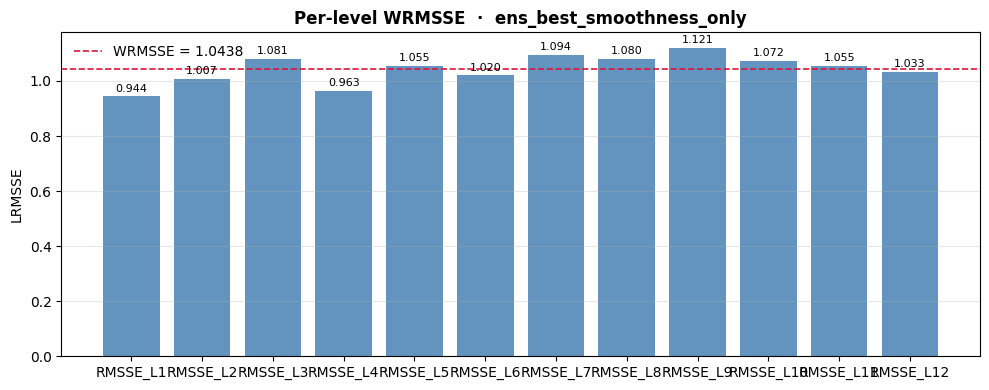

In [ ]:
# Per-level WRMSSE bar chart
level_keys   = sorted(metrics["level_scores"], key=lambda k: int(k.split("_L")[-1]))
level_scores = [metrics["level_scores"][k] for k in level_keys]
level_labels = [k.replace("LRMSSE_", "") for k in level_keys]

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(level_labels, level_scores, color="steelblue", alpha=0.85)
ax.axhline(metrics["WRMSSE"], color="crimson", linestyle="--", linewidth=1.2,
           label=f"WRMSSE = {metrics['WRMSSE']:.4f}")
ax.bar_label(bars, fmt="%.3f", fontsize=8, padding=2)
ax.set_ylabel("LRMSSE")
ax.set_title(f"Per-level WRMSSE  ·  {EXP_ENSEMBLE_TAG}", fontweight="bold")
ax.legend(frameon=False)
ax.grid(axis="y", alpha=0.3)
fig.tight_layout()
plt.show()

In [ ]:
from pathlib import Path
import json

out_dir = Path(f"/mnt/lab/nmwamsojo/results")
out_dir.mkdir(parents=True, exist_ok=True)

out_metrics = out_dir / f"{EXP_ENSEMBLE_TAG}_{CUTOFF_DAY.replace('-', '')}_metrics.json"
with open(out_metrics, "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print(f"Metrics  saved \u2192 {out_metrics}")

out_fcst = out_dir / f"{EXP_ENSEMBLE_TAG}_{CUTOFF_DAY.replace('-', '')}_forecasts.parquet"
ensemble_fcst.to_parquet(out_fcst, index=False)
print(f"Forecast saved \u2192 {out_fcst}  ({len(ensemble_fcst):,} rows)")

Metrics  saved → /mnt/lab/nmwamsojo/results/ens_best_smoothness_only_20160424_metrics.json
Forecast saved → /mnt/lab/nmwamsojo/results/ens_best_smoothness_only_20160424_forecasts.parquet  (853,720 rows)
